In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR    = r'D:\Tseng\圍棋\singletrials_timewindows'
BANDS       = ['Alpha', 'Beta', 'Delta', 'Gamma', 'Theta']
PARIETAL_CH = ['P3', 'P4', 'P7', 'P8', 'Pz', 'CP1', 'CP2', 'CP5', 'CP6']
GROUPS      = ['master', 'amateur', 'prof']
COLORS      = {'master': 'steelblue', 'amateur': 'darkorange', 'prof': 'forestgreen'}

time_vals = [x / 10 for x in range(5, 195, 5)]
TIME_COLS = []
for v in time_vals:
    int_part = int(v)
    dec_part = round((v - int_part) * 10)
    TIME_COLS.append(f'T_{int_part}_{dec_part}s')

df_raw = pd.read_csv(f'{DATA_DIR}\\Original_Alpha.csv')
df_raw['Step'] = pd.to_numeric(df_raw['Step'], errors='coerce')

df_trials = (
    df_raw[df_raw['Channel'].isin(PARIETAL_CH)]
    .groupby(['Group', 'SubjectID', 'Session', 'Epoch'], as_index=False)['Step']
    .first()
    .dropna(subset=['Step'])
)

print('Trial count per group:')
print(df_trials.groupby('Group').size())
print('\nStep NaN count:', df_trials['Step'].isna().sum())

In [ ]:
print('=== Step Descriptive Statistics ===')
for g in GROUPS:
    s = df_trials[df_trials['Group'] == g]['Step']
    print(f'\n[{g}]  N={len(s)}')
    print(f'  mean={s.mean():.4f}  std={s.std():.4f}')
    print(f'  min={s.min():.4f}  max={s.max():.4f}')
    print(f'  n_unique={s.nunique()}')
    print(f'  unique values: {sorted(s.unique())}')

In [ ]:
print('=== Step unique values per subject ===')
for g in GROUPS:
    df_g = df_trials[df_trials['Group'] == g]
    print(f'\n[{g}]')
    for sub, grp in df_g.groupby('SubjectID'):
        n_unique = grp['Step'].nunique()
        vals = sorted(grp['Step'].unique())
        print(f'  {sub}: {n_unique} unique  {vals}')

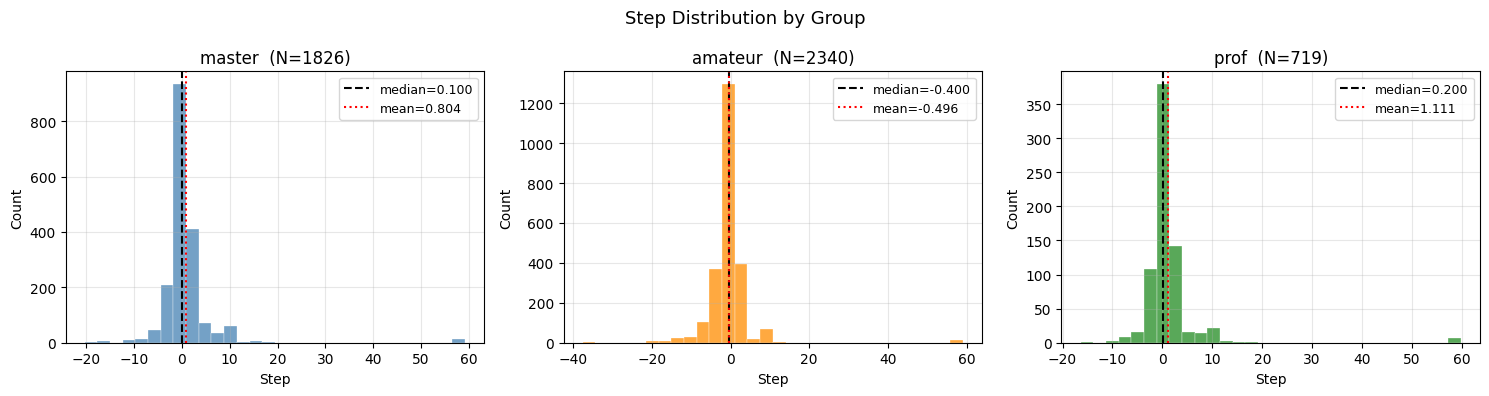

In [4]:
# ── Step 分布視覺化 ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for col, g in enumerate(GROUPS):
    s = df_trials[df_trials['Group'] == g]['Step']
    ax = axes[col]
    ax.hist(s, bins=30, color=COLORS[g], alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(s.median(), color='black', linestyle='--', lw=1.5, label=f'median={s.median():.3f}')
    ax.axvline(s.mean(),   color='red',   linestyle=':',  lw=1.5, label=f'mean={s.mean():.3f}')
    ax.set_title(f'{g}  (N={len(s)})', fontsize=12)
    ax.set_xlabel('Step')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Step Distribution by Group', fontsize=13)
plt.tight_layout()
plt.savefig(r'd:\Tseng\game_eeg\winstep_predict\step_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
dfs = {}
for band in BANDS:
    dfs[band] = pd.read_csv(f'{DATA_DIR}\\Original_{band}.csv')
print('Loaded all bands.')

def preprocess_group(dfs, group):
    band_feats = {}
    step_ref = None

    for band in BANDS:
        df = dfs[band]
        df_g = df[(df['Group'] == group) &
                  (df['Channel'].isin(PARIETAL_CH))].copy()
        df_g['Step'] = pd.to_numeric(df_g['Step'], errors='coerce')

        bad = df_g[df_g['Step'].isna()][['SubjectID','Session','Epoch']].drop_duplicates()
        if len(bad):
            print(f'[{group}/{band}] removing {len(bad)} invalid Step trials')
            df_g = df_g[~df_g.set_index(['SubjectID','Session','Epoch']).index.isin(
                bad.set_index(['SubjectID','Session','Epoch']).index)]

        grp  = df_g.groupby(['SubjectID','Session','Epoch'])
        avg  = grp[TIME_COLS].mean()
        step = grp['Step'].first()

        avg_norm = avg.div(avg.sum(axis=1), axis=0)
        avg_norm.columns = [f'{band}_{c}' for c in TIME_COLS]

        band_feats[band] = avg_norm
        if step_ref is None:
            step_ref = step
        else:
            assert avg_norm.index.equals(step_ref.index), f'{band} index mismatch'

    X = pd.concat([band_feats[b] for b in BANDS], axis=1)
    y = step_ref.rename('Step')
    print(f'[{group}] X={X.shape}  Step={y.min():.4f}~{y.max():.4f}  n_unique={y.nunique()}')
    return X, y


X_master,  y_master  = preprocess_group(dfs, 'master')
X_amateur, y_amateur = preprocess_group(dfs, 'amateur')
X_prof,    y_prof    = preprocess_group(dfs, 'prof')

In [ ]:
import os
out_dir = r'd:\Tseng\game_eeg\winstep_predict'

for X, y, g in [(X_master, y_master, 'master'),
                (X_amateur, y_amateur, 'amateur'),
                (X_prof, y_prof, 'prof')]:
    df_out = X.copy()
    df_out['Step'] = y
    df_out = df_out.reset_index()
    path = os.path.join(out_dir, f'{g}_parietal_190d.csv')
    df_out.to_csv(path, index=False)
    print(f'Saved: {path}  shape={df_out.shape}')